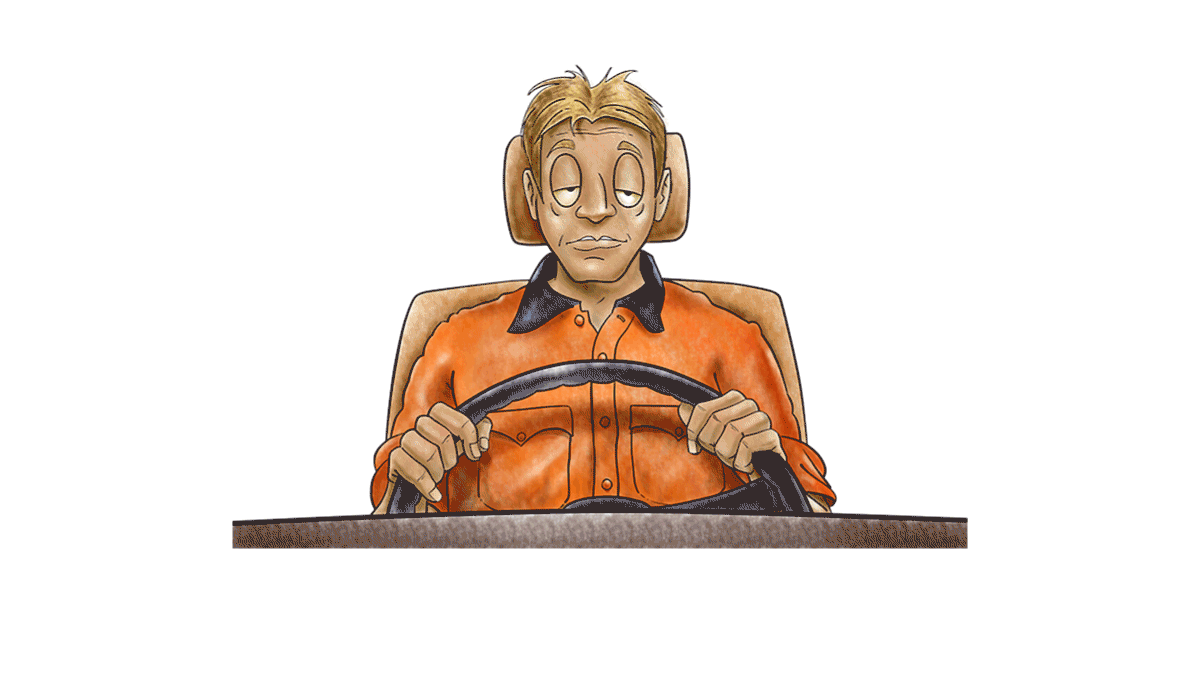

## Driver drowsiness detection is a car safety technology which helps prevent accidents caused by the driver getting drowsy. Various studies have suggested that around 20% of all road accidents are fatigue-related, up to 50% on certain roads.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import cv2


# labels

In [2]:
labels = os.listdir("C:/Users/KVK/Dropbox/PC/Downloads/train")


In [3]:
labels


['Closed', 'no_yawn', 'Open', 'yawn']

# visualize random 1 image

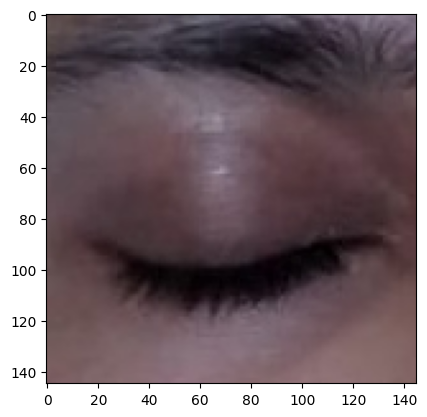

In [4]:
import matplotlib.pyplot as plt
plt.imshow(plt.imread("C:/Users/KVK/Dropbox/PC/Downloads/train/Closed/_0.jpg"))


# image array

In [5]:
a = plt.imread("C:/Users/KVK/Dropbox/PC/Downloads/train/yawn/10.jpg")


# image shape

In [6]:
a.shape


(480, 640, 3)

# visualize yawn image. 
# Here background is unnecessary. we need only face image array

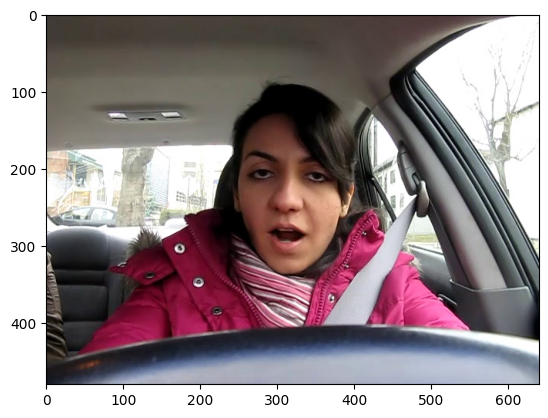

In [7]:
plt.imshow(plt.imread("C:/Users/KVK/Dropbox/PC/Downloads/train/yawn/10.jpg"))


# for yawn and not_yawn. Take only face

In [8]:
def face_for_yawn(direc="C:/Users/KVK/Dropbox/PC/Downloads/train", face_cas_path="C:/Users/KVK/Dropbox/PC/Downloads/haarcascade_frontalface_default.xml"):
    yaw_no = []
    IMG_SIZE = 145
    categories = ["yawn", "no_yawn"]
    for category in categories:
        path_link = os.path.join(direc, category)
        class_num1 = categories.index(category)
        print(class_num1)
        for image in os.listdir(path_link):
            image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)
            face_cascade = cv2.CascadeClassifier(face_cas_path)
            faces = face_cascade.detectMultiScale(image_array, 1.3, 5)
            for (x, y, w, h) in faces:
                img = cv2.rectangle(image_array, (x, y), (x+w, y+h), (0, 255, 0), 2)
                roi_color = img[y:y+h, x:x+w]
                resized_array = cv2.resize(roi_color, (IMG_SIZE, IMG_SIZE))
                yaw_no.append([resized_array, class_num1])
    return yaw_no


yawn_no_yawn = face_for_yawn()


0
1


# for closed and open eye

In [9]:
def get_data(dir_path="C:/Users/KVK/Dropbox/PC/Downloads/train/", face_cas="C:/Users/KVK/Dropbox/PC/Downloads/haarcascade_frontalface_default.xml", eye_cas=cv2.data.haarcascades + 'haarcascade_eye.xml'):
    labels = ['Closed', 'Open']
    IMG_SIZE = 145
    data = []
    for label in labels:
        path = os.path.join(dir_path, label)
        class_num = labels.index(label)
        class_num +=2
        print(class_num)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    return data


In [13]:
data_train = get_data()


2
3


# extend data and convert array

In [10]:
def append_data():
#     total_data = []
    yaw_no = face_for_yawn()
    data = get_data()
    yaw_no.extend(data)
    return yaw_no # Return list to avoid numpy shape mismatch errors


# new variable to store

In [11]:
new_data = append_data()


0
1
2
3


# separate label and features

In [12]:
X = []
y = []
for feature, label in new_data:
    X.append(feature)
    y.append(label)


# reshape the array

In [14]:
X = np.array(X, dtype=object) # Use object dtype to handle potentially different shapes before final reshape
X = X.reshape(-1, 145, 145, 3)


# LabelBinarizer

In [15]:
from sklearn.preprocessing import LabelBinarizer
label_bin = LabelBinarizer()
y = label_bin.fit_transform(y)


# label array

In [16]:
y = np.array(y)


# train test split

In [17]:
from sklearn.model_selection import train_test_split
seed = 42
test_size = 0.30
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=test_size)


# length of X_test

In [18]:
len(X_test)


578

# Not necessary, only use to matching with my pc version

In [19]:
# !pip install tensorflow==2.3.1
# !pip install keras==2.4.3


# import some dependencies

In [19]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf


# tensorflow version

In [20]:
tf.__version__


'2.13.0'

# keras version

In [21]:
import keras
keras.__version__


'2.13.1'

# Data Augmentation

In [22]:
train_generator = ImageDataGenerator(rescale=1/255, zoom_range=0.2, horizontal_flip=True, rotation_range=30)
test_generator = ImageDataGenerator(rescale=1/255)

train_generator = train_generator.flow(np.array(X_train), y_train, shuffle=False)
test_generator = test_generator.flow(np.array(X_test), y_test, shuffle=False)


# Model

In [23]:
model = Sequential()

model.add(Conv2D(256, (3, 3), activation="relu", input_shape=X_train.shape[1:]))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())
model.add(Dropout(0.5))

model.add(Dense(64, activation="relu"))
model.add(Dense(4, activation="softmax"))

model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 143, 143, 256)     7168      
                                                                 
 max_pooling2d (MaxPooling2  (None, 71, 71, 256)       0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 69, 69, 128)       295040    
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 34, 34, 128)       0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 64)        73792     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 64)        0

In [24]:
history = model.fit(train_generator, epochs=50, validation_data=test_generator, shuffle=True, validation_steps=len(test_generator))


Epoch 1/50
43/43 [==============================] - 246s 6s/step - loss: 1.1410 - accuracy: 0.5182 - val_loss: 0.4394 - val_accuracy: 0.8356
Epoch 2/50
43/43 [==============================] - 252s 6s/step - loss: 0.4526 - accuracy: 0.8144 - val_loss: 0.3994 - val_accuracy: 0.7958
Epoch 3/50
43/43 [==============================] - 260s 6s/step - loss: 0.3895 - accuracy: 0.8396 - val_loss: 0.3903 - val_accuracy: 0.8235
Epoch 4/50
43/43 [==============================] - 174s 4s/step - loss: 0.3530 - accuracy: 0.8515 - val_loss: 0.3136 - val_accuracy: 0.8824
Epoch 5/50
43/43 [==============================] - 163s 4s/step - loss: 0.3126 - accuracy: 0.8768 - val_loss: 0.2319 - val_accuracy: 0.9135
Epoch 6/50
43/43 [==============================] - 203s 5s/step - loss: 0.2709 - accuracy: 0.8901 - val_loss: 0.2222 - val_accuracy: 0.9031
Epoch 7/50
43/43 [==============================] - 191s 4s/step - loss: 0.2587 - accuracy: 0.8938 - val_loss: 0.3288 - val_accuracy: 0.8443
Epoch 8/50
43

# history

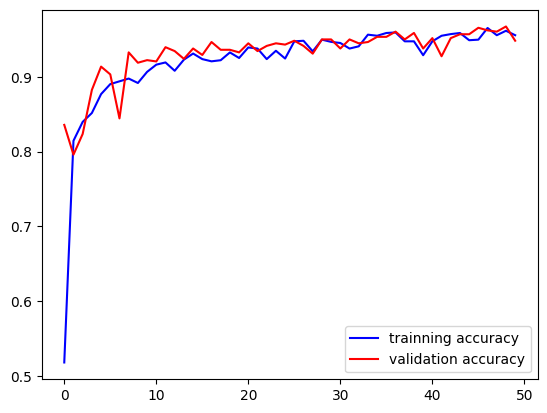

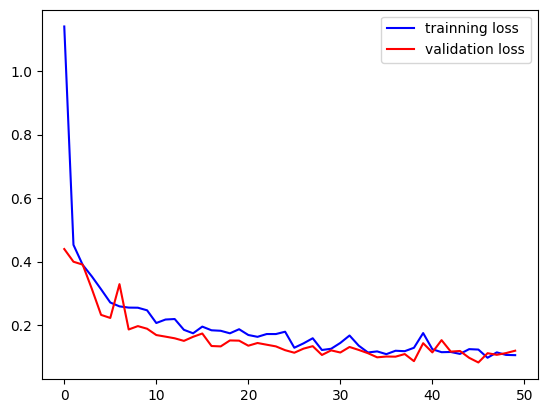

In [25]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, "b", label="trainning accuracy")
plt.plot(epochs, val_accuracy, "r", label="validation accuracy")
plt.legend()
plt.show()

plt.plot(epochs, loss, "b", label="trainning loss")
plt.plot(epochs, val_loss, "r", label="validation loss")
plt.legend()
plt.show()


# save model

In [26]:
model.save("drowiness_new6.h5")


c:\Users\KVK\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [27]:
model.save("drowiness_new6.model")


INFO:tensorflow:Assets written to: drowiness_new6.model\assets


INFO:tensorflow:Assets written to: drowiness_new6.model\assets


# Prediction

In [29]:
X_test = np.array(X_test.tolist()).astype('float32')
prediction = np.argmax(model.predict(X_test), axis=-1)


19/19 [==============================] - 18s 880ms/step


In [30]:
prediction


array([3, 3, 2, 3, 1, 3, 3, 2, 1, 2, 3, 3, 3, 2, 2, 2, 3, 0, 0, 3, 1, 3,
       2, 1, 1, 2, 2, 2, 3, 2, 3, 2, 3, 2, 0, 3, 3, 3, 1, 3, 3, 3, 2, 3,
       2, 2, 3, 3, 3, 3, 3, 1, 3, 1, 3, 3, 2, 2, 2, 0, 3, 3, 1, 2, 2, 3,
       2, 3, 2, 2, 1, 3, 3, 3, 2, 0, 1, 3, 1, 3, 2, 0, 3, 2, 3, 2, 2, 1,
       3, 3, 2, 3, 3, 3, 1, 0, 3, 0, 3, 3, 3, 1, 3, 1, 2, 3, 2, 1, 2, 0,
       1, 1, 2, 0, 0, 3, 3, 3, 2, 2, 3, 3, 2, 0, 1, 2, 3, 3, 0, 0, 3, 3,
       0, 3, 1, 2, 3, 3, 2, 1, 2, 2, 2, 1, 3, 3, 3, 3, 2, 0, 3, 3, 3, 3,
       3, 1, 1, 0, 3, 1, 3, 2, 2, 3, 2, 3, 3, 2, 3, 2, 3, 1, 2, 0, 3, 2,
       3, 2, 0, 2, 3, 0, 2, 1, 3, 2, 3, 1, 2, 0, 1, 3, 2, 2, 2, 3, 3, 0,
       3, 2, 3, 0, 2, 0, 0, 1, 2, 3, 2, 0, 3, 1, 2, 2, 2, 2, 1, 3, 1, 0,
       1, 0, 2, 3, 3, 3, 3, 0, 1, 2, 1, 0, 3, 3, 0, 3, 3, 1, 3, 3, 0, 1,
       0, 0, 3, 3, 3, 3, 3, 2, 3, 3, 2, 3, 2, 0, 2, 2, 2, 1, 3, 3, 2, 2,
       3, 2, 2, 0, 2, 3, 2, 2, 2, 3, 3, 3, 3, 3, 0, 1, 0, 3, 3, 3, 3, 2,
       2, 1, 2, 2, 2, 3, 3, 0, 2, 2, 1, 3, 2, 3, 1,

# classification report

In [31]:
labels_new = ["yawn", "no_yawn", "Closed", "Open"]


In [32]:
from sklearn.metrics import classification_report
print(classification_report(np.argmax(y_test, axis=1), prediction, target_names=labels_new))


              precision    recall  f1-score   support

        yawn       0.81      0.86      0.83        63
     no_yawn       0.84      0.86      0.85        74
      Closed       0.99      0.94      0.96       215
        Open       0.96      0.98      0.97       226

    accuracy                           0.94       578
   macro avg       0.90      0.91      0.90       578
weighted avg       0.94      0.94      0.94       578



# predicting function

In [7]:
import tensorflow as tf
import cv2
import numpy as np
import os

labels_new = ["yawn", "no_yawn", "Closed", "Open"]
IMG_SIZE = 145

def prepare(filepath, face_cas="haarcascade_frontalface_default.xml"):
    img_array = cv2.imread(filepath, cv2.IMREAD_COLOR)
    if img_array is None:
        raise ValueError(f"Could not read image from {filepath}. Please check the path.")
    
    # Detect and crop face (added to match training)
    face_cascade = cv2.CascadeClassifier(face_cas)
    
    # Check if empty and try absolute path as fallback
    if face_cascade.empty():
        face_cascade = cv2.CascadeClassifier("C:/Users/KVK/Dropbox/PC/Downloads/" + face_cas)
        
    if face_cascade.empty():
        raise ValueError(f"Could not load cascade classifier. Please ensure {face_cas} is in the same directory as this notebook.")
        
    faces = face_cascade.detectMultiScale(img_array, 1.3, 5)
    for (x, y, w, h) in faces:
        img_array = img_array[y:y+h, x:x+w]
        break
        
    # Normalize and Resize
    img_array = img_array / 255.0
    resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
    return resized_array.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

model = tf.keras.models.load_model("./drowiness_new6.h5")


# Prediction 
## 0-yawn, 1-no_yawn, 2-Closed, 3-Open

In [8]:
# prepare("C:/Users/KVK/Dropbox/PC/Downloads/train/no_yawn/1068.jpg")
prediction = model.predict(prepare("C:/Users/KVK/Dropbox/PC/Downloads/train/no_yawn/1067.jpg"))
print(f'Predicted Class Index: {np.argmax(prediction)}')
print(f'Predicted Label: {labels_new[np.argmax(prediction)]}')


1/1 [==============================] - 0s 201ms/step
Predicted Class Index: 1
Predicted Label: no_yawn


In [9]:
# prepare("C:/Users/KVK/Dropbox/PC/Downloads/train/no_yawn/1068.jpg")
prediction = model.predict(prepare("C:/Users/KVK/Dropbox/PC/Downloads/train/no_yawn/1067.jpg"))
print(f'Predicted Class Index: {np.argmax(prediction)}')
print(f'Predicted Label: {labels_new[np.argmax(prediction)]}')


1/1 [==============================] - 0s 42ms/step
Predicted Class Index: 1
Predicted Label: no_yawn


In [10]:
# prepare("C:/Users/KVK/Dropbox/PC/Downloads/train/no_yawn/1068.jpg")
prediction = model.predict(prepare("C:/Users/KVK/Dropbox/PC/Downloads/train/no_yawn/1067.jpg"))
print(f'Predicted Class Index: {np.argmax(prediction)}')
print(f'Predicted Label: {labels_new[np.argmax(prediction)]}')


1/1 [==============================] - 0s 56ms/step
Predicted Class Index: 1
Predicted Label: no_yawn


In [11]:
# prepare("C:/Users/KVK/Dropbox/PC/Downloads/train/no_yawn/1068.jpg")
prediction = model.predict(prepare("C:/Users/KVK/Dropbox/PC/Downloads/train/no_yawn/1067.jpg"))
print(f'Predicted Class Index: {np.argmax(prediction)}')
print(f'Predicted Label: {labels_new[np.argmax(prediction)]}')


1/1 [==============================] - 0s 40ms/step
Predicted Class Index: 1
Predicted Label: no_yawn


In [13]:
prediction = model.predict([prepare("C:/Users/KVK/Dropbox/PC/Downloads/train/Open/_104.jpg")])
print(f'Predicted Class Index: {np.argmax(prediction)}')
print(f'Predicted Label: {labels_new[np.argmax(prediction)]}')

1/1 [==============================] - 0s 63ms/step
Predicted Class Index: 3
Predicted Label: Open
